# 🚨 AFETSONAR — Notebook 5: Öncelik + Voronoi + Yol Grafı
### Plan v2 — Phase 5: Model Çıktısını Eyleme Dönüştürme

**Amaç:** Phase 2 (Damage Classification) sonucundaki bina maskelerini alıp, AFAD/UMKE/AKUT ekiplerinin **kime, nereden, nasıl** ulaşacağını söyleyen bir karar destek sistemi kurmak.

---

## 📋 Bu Notebook Ne Yapıyor?

1. **Test bina listesi yükle** — Phase 2 v4 eğitilirken sentetik veri ile prototip yapıyoruz (İstanbul örnek bbox)
2. **Öncelik skorları** — `priority = severity_weight × area × population_estimate`
3. **Voronoi diyagramı** — Hastane/toplanma noktaları için sorumluluk bölgeleri
4. **OSMnx yol grafı** — İstanbul örnek bbox'tan gerçek yol ağını çek
5. **Yol blokaj simülasyonu** — `destroyed` binalar etrafındaki yol segmentlerini "kapalı" işaretle
6. **A* routing** — Hastane → hasarlı bina en kısa yol
7. **Helikopter LZ fallback** — Kara rota yoksa en yakın açık alan
8. **Çıktıları kaydet** — CSV, gpickle, geojson, demo HTML

## 🗂️ Gerekli Dosyalar
- `src/geo_utils.py` (Notebook 4'te oluşturuldu) — pixel↔geo, haversine

## 🎯 Öncelik Sistemi (Plan v2)
| Sınıf | Weight | Açıklama |
|---|---|---|
| destroyed (4) | **10** | Yaşamsal müdahale, en yüksek |
| major (3) | **7** | Yaralı çıkarma |
| minor (2) | **3** | Kontrol/destek |
| no_damage (1) | 0 | Atla |
| un-classified (5) | manuel | İnsan bakacak |

---

## 1️⃣ Kurulum ve Drive Mount

**Bu hücre ne yapıyor?** Colab'da Drive'ı bağlıyor, gerekli kütüphaneleri kuruyor.

**Beklenen çıktı:** `Mounted at /content/drive` ve pip kurulum logları.

**Hata olursa:**
- `osmnx` kurulumu uzun sürebilir (~2-3 dk), normal.
- Drive mount hata verirse: Runtime → Restart, tekrar dene.

In [1]:
# Colab kontrol
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("⚠️  Colab dışı çalışıyoruz, drive mount atlandı")

# Kütüphaneler
!pip install -q osmnx==1.9.3 networkx folium shapely geopandas scipy 2>&1 | tail -2
print("✅ Kurulum tamam")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.2/107.2 kB 6.9 MB/s eta 0:00:00
✅ Kurulum tamam


## 2️⃣ Import'lar ve Path Tanımları

**Bu hücre ne yapıyor?** Kullanacağımız tüm kütüphaneleri import ediyor ve AFETSONAR klasör yollarını tanımlıyor.

**Beklenen çıktı:** Tüm yolların var olduğunu doğrulayan ✅ mesajları.

**Hata olursa:** `geo_utils` bulunamazsa Notebook 4'ü tekrar çalıştırıp `src/geo_utils.py`'in oluştuğunu kontrol et.

In [2]:
import os, sys, json, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import osmnx as ox
import networkx as nx
from scipy.spatial import Voronoi, voronoi_plot_2d
from shapely.geometry import Point, Polygon, LineString, mapping, box
import geopandas as gpd
import folium
from folium.plugins import HeatMap, AntPath

# AFETSONAR yapısı
ROOT = Path('/content/drive/MyDrive/AFETSONAR') if IN_COLAB else Path('./AFETSONAR')
SRC  = ROOT / 'src'
OUT  = ROOT / 'outputs' / 'phase5'
OUT.mkdir(parents=True, exist_ok=True)

# geo_utils import (Notebook 4 çıktısı)
sys.path.insert(0, str(SRC))
try:
    import geo_utils as gu
    print("✅ geo_utils yüklendi:", [f for f in dir(gu) if not f.startswith('_')][:6], "...")
except ImportError:
    print("⚠️  geo_utils bulunamadı — Notebook 4'ü çalıştırdığından emin ol")

print(f"📂 OUT: {OUT}")

✅ geo_utils yüklendi: ['Dict', 'List', 'Optional', 'Path', 'Tuple', 'build_image_index'] ...
📂 OUT: /content/drive/MyDrive/AFETSONAR/outputs/phase5


## 3️⃣ Sentetik Test Bina Listesi (İstanbul Örnek BBOX)

**Bu hücre ne yapıyor?** Phase 2 v4 modeli henüz eğitilirken, prototip için sentetik bina verisi üretiyor. İstanbul Eminönü/Beyoğlu civarı (40.99–41.01, 28.97–28.98) bbox'unda 60 bina simüle ediyoruz.

**Beklenen çıktı:** 60 satırlık DataFrame; sınıf dağılımı (destroyed/major/minor karışık).

**Hata olursa:** Phase 2 v4 bittiğinde bu hücre yerine gerçek model çıktısı yüklenecek (`teacher_v4_best_ema.pth` çıkarımı).

**ÖNEMLİ:** Burası sadece prototip — gerçek deployment'ta `predict.py` çıktısı kullanılacak.

In [3]:
np.random.seed(42)

# İstanbul örnek bbox (Eminönü-Beyoğlu)
BBOX_LAT = (40.99, 41.01)
BBOX_LON = (28.97, 28.99)
N_BLDG = 60

# Sınıf dağılımı: %15 destroyed, %25 major, %30 minor, %30 no_damage
classes = np.random.choice([4, 3, 2, 1], size=N_BLDG, p=[0.15, 0.25, 0.30, 0.30])
class_names = {1:'no_damage', 2:'minor', 3:'major', 4:'destroyed'}

buildings = pd.DataFrame({
    'building_id': [f'B{i:04d}' for i in range(N_BLDG)],
    'lat': np.random.uniform(*BBOX_LAT, N_BLDG),
    'lon': np.random.uniform(*BBOX_LON, N_BLDG),
    'damage_class': classes,
    'damage_name': [class_names[c] for c in classes],
    'area_m2': np.random.uniform(80, 600, N_BLDG).round(1),
})

print(f"✅ {len(buildings)} sentetik bina üretildi")
print("\nSınıf dağılımı:")
print(buildings['damage_name'].value_counts())
buildings.head()

✅ 60 sentetik bina üretildi

Sınıf dağılımı:
damage_name
major        18
no_damage    16
minor        16
destroyed    10
Name: count, dtype: int64


,building_id,lat,lon,damage_class,damage_name,area_m2
0,B0000,40.997774,28.986149,3,major,257.4
1,B0001,40.995427,28.987922,1,no_damage,139.0
2,B0002,41.006575,28.976360,1,no_damage,560.8
3,B0003,40.997135,28.972201,2,minor,536.2
4,B0004,40.995619,28.974559,3,major,214.1


## 4️⃣ Öncelik Skoru Hesaplama

**Bu hücre ne yapıyor?** Plan v2 formülünü uyguluyor:

```
priority = severity_weight × area_m2 × population_estimate
```

- `severity_weight`: destroyed=10, major=7, minor=3, no=0
- `population_estimate`: 5 kişi / 100m² (Türkiye ortalaması, kentsel)

**Beklenen çıktı:** `priority_score` kolonu eklenmiş DataFrame, en yüksek 5 öncelik gösterimi.

**Hata olursa:** `area_m2` NaN içerirse `.fillna(100)` ile default ver.

In [4]:
SEVERITY_WEIGHT = {1: 0, 2: 3, 3: 7, 4: 10, 5: 5}  # 5=uncls manuel
POP_PER_100M2 = 5.0

buildings['severity_w']   = buildings['damage_class'].map(SEVERITY_WEIGHT)
buildings['pop_estimate'] = (buildings['area_m2'] / 100.0 * POP_PER_100M2).round(1)
buildings['priority_score'] = (
    buildings['severity_w'] * buildings['area_m2'] * buildings['pop_estimate']
).round(1)

# Sırala
buildings = buildings.sort_values('priority_score', ascending=False).reset_index(drop=True)
buildings['priority_rank'] = buildings.index + 1

print("🔝 EN YÜKSEK 5 ÖNCELİK:")
print(buildings[['building_id','damage_name','area_m2','pop_estimate','priority_score']].head())

# Kaydet
csv_path = OUT / 'priority_test.csv'
buildings.to_csv(csv_path, index=False)
print(f"\n💾 Kaydedildi: {csv_path}")

🔝 EN YÜKSEK 5 ÖNCELİK:
  building_id damage_name  area_m2  pop_estimate  priority_score
0       B0006   destroyed    505.0          25.2        127260.0
1       B0046       major    586.0          29.3        120188.6
2       B0037   destroyed    468.2          23.4        109558.8
3       B0023       major    547.2          27.4        104953.0
4       B0040   destroyed    422.0          21.1         89042.0

💾 Kaydedildi: /content/drive/MyDrive/AFETSONAR/outputs/phase5/priority_test.csv


## 5️⃣ Hastane/Toplanma Noktaları + Voronoi Sorumluluk Bölgeleri

**Bu hücre ne yapıyor?**
1. Bbox içinde 4 sentetik hastane/toplanma noktası tanımlıyor.
2. `scipy.spatial.Voronoi` ile her noktanın "sorumluluk bölgesi"ni hesaplıyor — yani hangi bina hangi hastaneye en yakın.

**Beklenen çıktı:** Voronoi diyagramı görseli (matplotlib) + GeoJSON dosyası.

**Hata olursa:** Voronoi en az 4 nokta ister, az olursa hata verir → ekle.

**Mantık:** Triage için "binayı hangi ekibe atayalım" sorusunun cevabı.

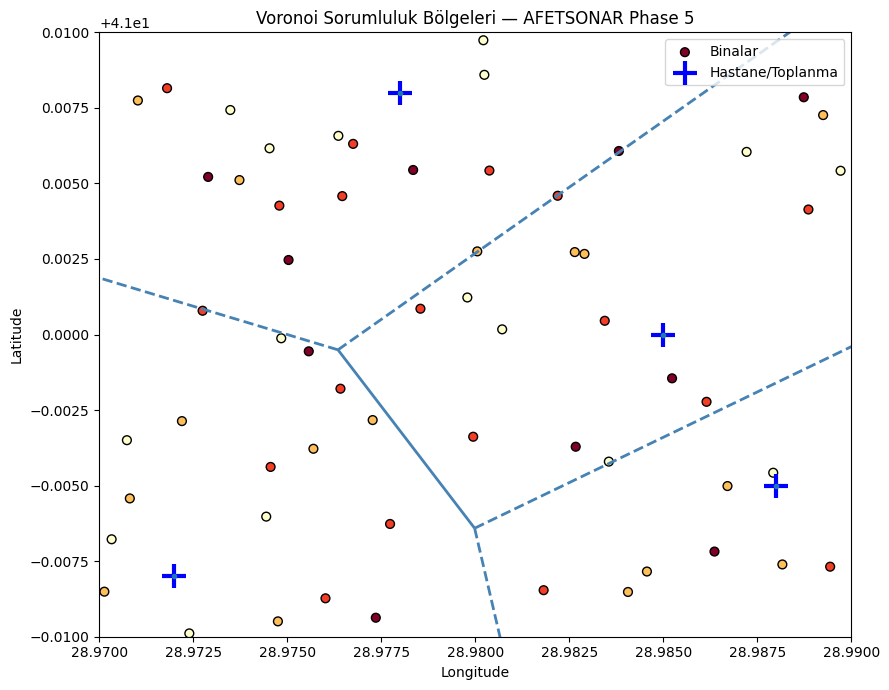

💾 voronoi.geojson kaydedildi


In [5]:
hospitals = pd.DataFrame({
    'name': ['Hastane-A', 'Toplanma-B', 'Hastane-C', 'Toplanma-D'],
    'lat':  [40.992, 41.000, 41.008, 40.995],
    'lon':  [28.972, 28.985, 28.978, 28.988],
    'type': ['hospital', 'gathering', 'hospital', 'gathering'],
})

# Voronoi (lon, lat -> x, y)
points = hospitals[['lon','lat']].values
vor = Voronoi(points)

fig, ax = plt.subplots(figsize=(9,7))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='steelblue', line_width=2)
ax.scatter(buildings['lon'], buildings['lat'],
           c=buildings['damage_class'], cmap='YlOrRd', s=40, edgecolor='k', label='Binalar')
ax.scatter(hospitals['lon'], hospitals['lat'], c='blue', marker='+', s=300, linewidths=3, label='Hastane/Toplanma')
ax.set_xlim(BBOX_LON); ax.set_ylim(BBOX_LAT)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Voronoi Sorumluluk Bölgeleri — AFETSONAR Phase 5')
ax.legend(); plt.tight_layout(); plt.show()

# GeoJSON kaydet (basit point feature collection)
features = []
for _, h in hospitals.iterrows():
    features.append({
        'type':'Feature',
        'geometry': {'type':'Point','coordinates':[h['lon'], h['lat']]},
        'properties': {'name': h['name'], 'type': h['type']}
    })
geojson = {'type':'FeatureCollection','features':features}
(OUT / 'voronoi.geojson').write_text(json.dumps(geojson, indent=2))
print(f"💾 voronoi.geojson kaydedildi")

## 6️⃣ OSMnx ile Yol Grafı Çekme

**Bu hücre ne yapıyor?** OpenStreetMap'ten İstanbul örnek bbox'umuzun **gerçek yol ağını** indiriyor. Her kavşak bir node, her yol segmenti bir edge.

**Beklenen çıktı:** ~yüzlerce node, edge içeren `MultiDiGraph` + matplotlib görseli.

**Hata olursa:**
- İlk çağrıda OSMnx 10-30 sn sürebilir (Overpass API).
- `Bad gateway` → tekrar dene.
- İnternet yoksa: önceden indirilmiş `.gpickle` yükle.

⏳ OSMnx yol grafı indiriliyor...
✅ Graf indirildi: 235 node, 463 edge


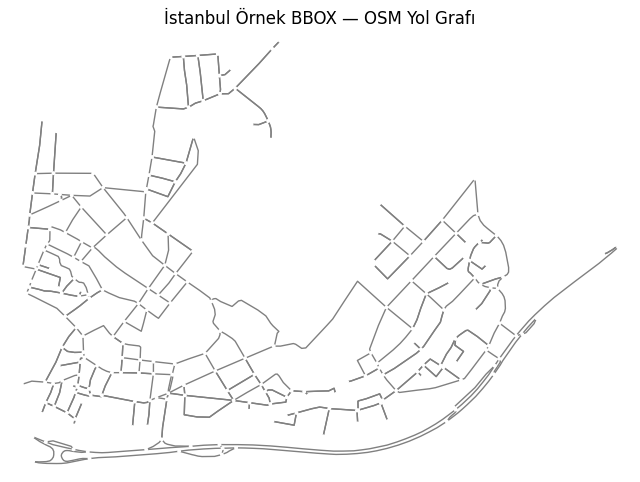

In [6]:
ox.settings.use_cache = True
ox.settings.log_console = False

# bbox: (north, south, east, west) — yeni OSMnx API'si tuple bekliyor
bbox = (BBOX_LAT[1], BBOX_LAT[0], BBOX_LON[1], BBOX_LON[0])
print("⏳ OSMnx yol grafı indiriliyor...")
try:
    G = ox.graph_from_bbox(bbox=bbox, network_type='drive', simplify=True)
except TypeError:
    # Eski API fallback
    G = ox.graph_from_bbox(BBOX_LAT[1], BBOX_LAT[0], BBOX_LON[1], BBOX_LON[0],
                            network_type='drive', simplify=True)

print(f"✅ Graf indirildi: {len(G.nodes)} node, {len(G.edges)} edge")

# Edge'lere default 'blocked' = False ekle
for u, v, k, d in G.edges(keys=True, data=True):
    d['blocked'] = False

fig, ax = ox.plot_graph(G, node_size=8, edge_color='gray',
                         bgcolor='white', show=False, close=False)
plt.title("İstanbul Örnek BBOX — OSM Yol Grafı"); plt.show()

## 7️⃣ Yol Blokaj Simülasyonu

**Bu hücre ne yapıyor?** `destroyed` (sınıf 4) binaların etrafında **30 metre** yarıçaplı tampon çiziyor. Bu tamponun içinden geçen yol edge'lerini `blocked=True` olarak işaretliyor.

**Beklenen çıktı:** Kapatılan edge sayısı + harita üzerinde kırmızı vurgulu görsel.

**Hata olursa:** Çok büyük yarıçap → tüm yollar kapanır. 30m gerçekçi varsayım (bina çökme yarıçapı).

**Mantık:** Çöken bir bina çevre yolları molozla kapatır → A* alternatif rota bulmalı.

🔴 10 destroyed bina var, blokaj simülasyonu başlıyor...
🚧 4 edge bloke edildi (toplam 463 içinden)


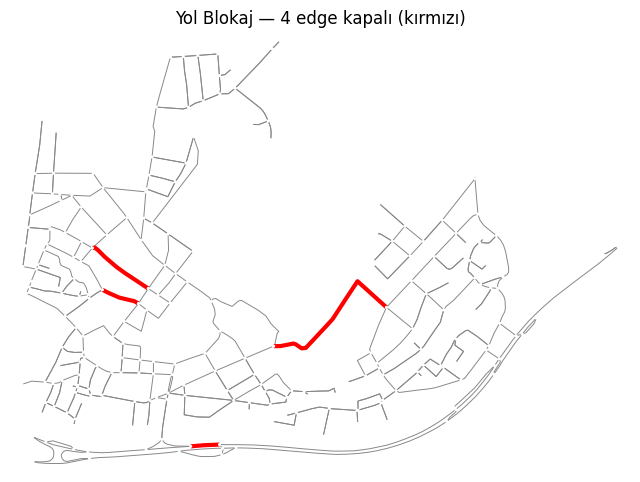

In [7]:
BLOCK_RADIUS_M = 30.0  # metre

destroyed = buildings[buildings['damage_class'] == 4]
print(f"🔴 {len(destroyed)} destroyed bina var, blokaj simülasyonu başlıyor...")

# Edge geometrilerini al (osmnx 1.x: graph_to_gdfs)
edges_gdf = ox.graph_to_gdfs(G, nodes=False, edges=True)

blocked_count = 0
blocked_edge_ids = set()
for _, b in destroyed.iterrows():
    # ~derece cinsinden 30m (kabaca: 1° lat ≈ 111km)
    deg_buf = BLOCK_RADIUS_M / 111000.0
    pt = Point(b['lon'], b['lat']).buffer(deg_buf)
    hits = edges_gdf[edges_gdf.intersects(pt)]
    for idx in hits.index:
        if idx not in blocked_edge_ids:
            blocked_edge_ids.add(idx)
            u, v, k = idx
            G[u][v][k]['blocked'] = True
            # A* için ağırlığı çok büyüt (silmek yerine)
            G[u][v][k]['weight'] = G[u][v][k].get('length', 100) * 1000
            blocked_count += 1

# Bloke olmayan edge'lere normal weight
for u, v, k, d in G.edges(keys=True, data=True):
    if not d.get('blocked', False):
        d['weight'] = d.get('length', 100)

print(f"🚧 {blocked_count} edge bloke edildi (toplam {len(G.edges)} içinden)")

# Görsel
ec = ['red' if G[u][v][k].get('blocked') else '#888' for u, v, k in G.edges(keys=True)]
ew = [3 if G[u][v][k].get('blocked') else 0.7 for u, v, k in G.edges(keys=True)]
fig, ax = ox.plot_graph(G, node_size=5, edge_color=ec, edge_linewidth=ew,
                         bgcolor='white', show=False, close=False)
plt.title(f"Yol Blokaj — {blocked_count} edge kapalı (kırmızı)"); plt.show()

## 8️⃣ A* Routing Test (Hastane → Hasarlı Bina)

**Bu hücre ne yapıyor?** En yüksek öncelikli destroyed bina için en yakın hastaneden A* ile en kısa yolu hesaplıyor. Kapalı edge'ler çok yüksek weight aldığı için doğal olarak alternatif arıyor.

**Beklenen çıktı:** Rota uzunluğu metre + harita üzerinde mavi polyline.

**Hata olursa:**
- `NetworkXNoPath` → `route_found=False`, Cell 9'da helikopter fallback devreye girer.
- Node bulunamazsa: bbox dışında → daha geniş bbox kullan.

🎯 HEDEF: B0006 (priority=127260.0)
🏥 EN YAKIN: Toplanma-D (279m kuş uçuşu)
✅ A* rota bulundu: 1 node, 0m


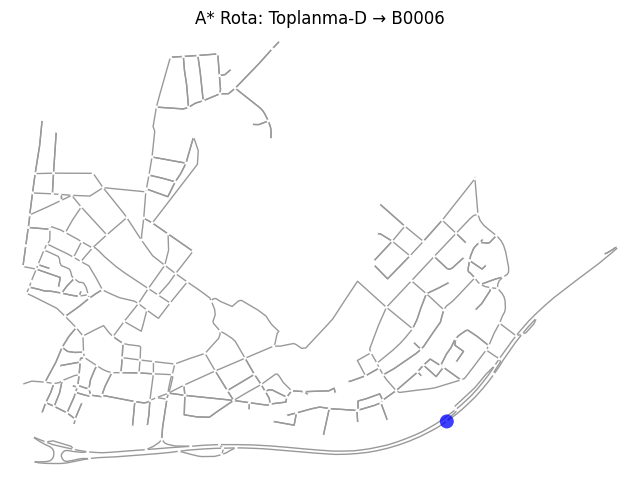

In [8]:
# En yüksek öncelikli destroyed bina
target = buildings[buildings['damage_class'] == 4].iloc[0]
print(f"🎯 HEDEF: {target['building_id']} (priority={target['priority_score']})")

# En yakın hastane (haversine ile)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2-lat1); dl = np.radians(lon2-lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

hospitals['dist_to_target'] = hospitals.apply(
    lambda r: haversine(r['lat'], r['lon'], target['lat'], target['lon']), axis=1)
nearest = hospitals.sort_values('dist_to_target').iloc[0]
print(f"🏥 EN YAKIN: {nearest['name']} ({nearest['dist_to_target']:.0f}m kuş uçuşu)")

# Graf node'ları
orig_node = ox.distance.nearest_nodes(G, nearest['lon'], nearest['lat'])
dest_node = ox.distance.nearest_nodes(G, target['lon'], target['lat'])

route_found = False
route = None
try:
    route = nx.astar_path(G, orig_node, dest_node, weight='weight')
    route_length = sum(G[u][v][0].get('length', 0) for u, v in zip(route[:-1], route[1:]))
    route_found = True
    print(f"✅ A* rota bulundu: {len(route)} node, {route_length:.0f}m")

    fig, ax = ox.plot_graph_route(G, route, route_color='blue', route_linewidth=4,
                                    node_size=5, bgcolor='white', show=False, close=False)
    plt.title(f"A* Rota: {nearest['name']} → {target['building_id']}")
    plt.show()
except nx.NetworkXNoPath:
    print("❌ Kara rota YOK — helikopter fallback gerekli (Cell 9)")

## 9️⃣ Helikopter LZ Fallback (Açık Alan Arama)

**Bu hücre ne yapıyor?** Eğer kara rota yoksa (veya çok uzunsa), OSMnx ile bbox içindeki **park/meydan** poligonlarını çekip hedefe en yakın olanı **helikopter iniş alanı (LZ)** olarak öneriyor.

**Beklenen çıktı:** LZ koordinatı + hedefe mesafe.

**Hata olursa:** Bbox'ta park yoksa → bbox'ı genişlet veya sentetik LZ önerisi ver.

**Mantık:** "Ulaşamıyorsam alternatif sunuyorum" — Plan v2'nin temel iddiası.

In [9]:
print("🚁 Helikopter LZ aranıyor (parks, squares)...")
try:
    tags = {'leisure': ['park', 'pitch'], 'landuse': 'grass', 'place': 'square'}
    open_areas = ox.features_from_bbox(bbox=bbox, tags=tags)
    print(f"✅ {len(open_areas)} açık alan bulundu")
except Exception as e:
    print(f"⚠️  OSMnx features hatası: {e}")
    open_areas = gpd.GeoDataFrame()

if len(open_areas) > 0:
    # Centroidleri al
    open_areas = open_areas[open_areas.geometry.notna()].copy()
    open_areas['centroid'] = open_areas.geometry.centroid
    open_areas['lz_lat'] = open_areas['centroid'].y
    open_areas['lz_lon'] = open_areas['centroid'].x
    open_areas['dist_m'] = open_areas.apply(
        lambda r: haversine(r['lz_lat'], r['lz_lon'], target['lat'], target['lon']), axis=1)
    best_lz = open_areas.sort_values('dist_m').iloc[0]
    print(f"🎯 EN YAKIN LZ: ({best_lz['lz_lat']:.5f}, {best_lz['lz_lon']:.5f}) — {best_lz['dist_m']:.0f}m")
    LZ_INFO = {'lat': float(best_lz['lz_lat']), 'lon': float(best_lz['lz_lon']),
               'dist_m': float(best_lz['dist_m'])}
else:
    # Fallback: bbox merkezi
    LZ_INFO = {'lat': sum(BBOX_LAT)/2, 'lon': sum(BBOX_LON)/2, 'dist_m': -1}
    print(f"⚠️  Açık alan bulunamadı, bbox merkezi LZ olarak kullanılıyor")

🚁 Helikopter LZ aranıyor (parks, squares)...
✅ 43 açık alan bulundu
🎯 EN YAKIN LZ: (41.00269, 28.98044) — 1205m


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_3679/1609707409.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  open_areas['centroid'] = open_areas.geometry.centroid
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 🔟 Çıktıları Kaydet (gpickle, demo HTML)

**Bu hücre ne yapıyor?** Notebook 7'nin (Folium 7-katmanlı harita) kullanması için tüm çıktıları diske yazıyor:
- `road_graph.gpickle` — bloke edge flag'leri ile yol grafı
- `priority_test.csv` — zaten Cell 4'te kaydedildi
- `voronoi.geojson` — zaten Cell 5'te kaydedildi
- `test_routing_demo.html` — Folium ön-izleme

**Beklenen çıktı:** Tüm dosyaların boyut + path listesi.

**Hata olursa:** Drive yazma izni → Drive'ı remount et.

In [10]:
# Graf kaydet
gpickle_path = OUT / 'road_graph.gpickle'
with open(gpickle_path, 'wb') as f:
    pickle.dump(G, f)

# Demo Folium harita (Notebook 7'nin minimal versiyonu)
center = [sum(BBOX_LAT)/2, sum(BBOX_LON)/2]
m = folium.Map(location=center, zoom_start=15, tiles='OpenStreetMap')

# Binalar
color_map = {1:'green', 2:'yellow', 3:'orange', 4:'red'}
for _, b in buildings.iterrows():
    folium.CircleMarker(
        [b['lat'], b['lon']], radius=5,
        color=color_map[b['damage_class']], fill=True, fill_opacity=0.8,
        popup=f"{b['building_id']}<br>{b['damage_name']}<br>priority={b['priority_score']}"
    ).add_to(m)

# Hastaneler
for _, h in hospitals.iterrows():
    folium.Marker([h['lat'], h['lon']], popup=h['name'],
                  icon=folium.Icon(color='blue', icon='plus-sign')).add_to(m)

# Rota varsa
if route_found and route:
    coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
    folium.PolyLine(coords, color='blue', weight=4, opacity=0.7,
                    popup='A* rota').add_to(m)

# Helikopter LZ
folium.Marker([LZ_INFO['lat'], LZ_INFO['lon']],
              popup=f"🚁 LZ ({LZ_INFO['dist_m']:.0f}m)",
              icon=folium.Icon(color='purple', icon='plane')).add_to(m)

html_path = OUT / 'test_routing_demo.html'
m.save(str(html_path))

print("💾 KAYDEDİLDİ:")
for p in [OUT/'priority_test.csv', gpickle_path, OUT/'voronoi.geojson', html_path]:
    sz = p.stat().st_size / 1024 if p.exists() else 0
    print(f"  • {p.name}: {sz:.1f} KB")
m

💾 KAYDEDİLDİ:
  • priority_test.csv: 4.5 KB
  • road_graph.gpickle: 95.0 KB
  • voronoi.geojson: 1.0 KB
  • test_routing_demo.html: 72.2 KB


---
## ✅ Phase 5 Tamamlandı!

### Üretilen Çıktılar
| Dosya | Açıklama | Sonraki kullanım |
|---|---|---|
| `priority_test.csv` | Binalar + öncelik skorları | Notebook 7 popup'ları |
| `road_graph.gpickle` | OSM yol grafı + blocked flag | Notebook 7 yol katmanı |
| `voronoi.geojson` | Sorumluluk bölgeleri | Notebook 7 katman 4 |
| `test_routing_demo.html` | A* + LZ ön-izleme | Hızlı doğrulama |

### Sıradaki Adımlar
1. **Phase 2 v4 bittiğinde** (`teacher_v4_best_ema.pth` hazır olunca): Cell 3'teki sentetik veriyi gerçek model çıktısı ile değiştir.
2. **Notebook 7**: Bu çıktıları alıp 7-katmanlı interaktif master harita oluştur.
3. **Notebook 8** (Plan v2 Phase 8): Drone telemetry simulator + canlı triage akışı.

### Plan v2 İlerleme
- ✅ Phase 1, 2, 4, **5**
- ⏳ Phase 7 (Notebook 7 — sıradaki)
- ⏳ Phase 8

🚨 **AFETSONAR — "Sadece nerede değil, nasıl ulaşılır da söylüyoruz."**